# Variable de "negatividad del tweet" y reentrenamiento del modelo

negatividad = (1 - vader_compound) / 2        # escala [0, 1]; 0 = muy positivo, 1 = muy negativo


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_STATE = 42
OUT = Path("../output"); OUT.mkdir(exist_ok=True)
pd.set_option("display.max_colwidth", 120)

## 1. Carga de los datos

Se usa train_sentiment.csv

In [15]:
df = pd.read_csv("../data/train_sentiment.csv")

assert "negatividad" in df.columns, "Falta la columna 'negatividad' (revisar notebook 04 de Persona 2)"
assert df["negatividad"].isna().sum() == 0, "Hay NaN en 'negatividad'"
assert df["text_final"].isna().sum() == 0, "Hay NaN en 'text_final'"

print("Filas:", len(df))
print("Rango negatividad:", round(df['negatividad'].min(), 3), "-", round(df['negatividad'].max(), 3))
df[["text", "text_final", "target", "vader_compound", "negatividad"]].head()

Filas: 7484
Rango negatividad: 0.014 - 0.994


,text,text_final,target,vader_compound,negatividad
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquake may allah forgive,1,0.2732,0.3634
1,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada,1,-0.3400,0.6700
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,resident asked shelter place notified officer evacuation shelter place order expected,1,-0.2960,0.6480
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfire evacuation order california,1,0.0000,0.5000
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo ruby alaska smoke wildfire pours school,1,0.0000,0.5000


## 2. Análisis de la variable negatividad


In [16]:
resumen = df.groupby("target")["negatividad"].agg(["mean", "median", "std"]).round(4)
resumen.index = ["0 - no desastre", "1 - desastre real"]
corr = df["negatividad"].corr(df["target"])
print(resumen)
print(f"\nCorrelacion negatividad <-> target: {corr:.4f}")

                     mean  median     std
0 - no desastre    0.5303   0.500  0.2289
1 - desastre real  0.6325   0.656  0.2144

Correlacion negatividad <-> target: 0.2212


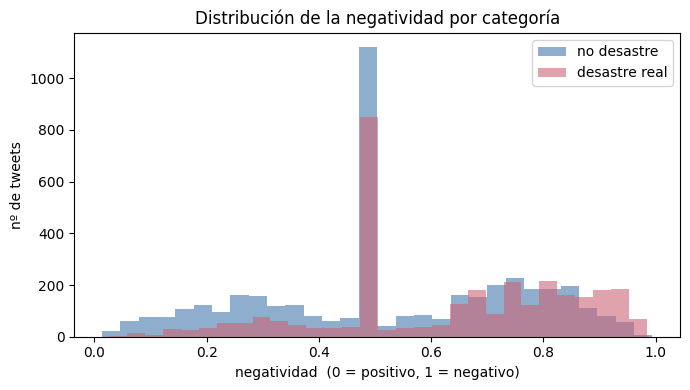

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
for t, color, lab in [(0, "#4477aa", "no desastre"), (1, "#cc6677", "desastre real")]:
    ax.hist(df.loc[df.target == t, "negatividad"], bins=30, alpha=0.6, color=color, label=lab)
ax.set_xlabel("negatividad  (0 = positivo, 1 = negativo)")
ax.set_ylabel("nº de tweets")
ax.set_title("Distribución de la negatividad por categoría")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "negatividad_por_categoria.png", dpi=150)
plt.show()

**Interpretación**

La variable de negatividad sí muestra una diferencia entre las dos clases, pero débil. Los tweets de desastre real son en promedio más negativos (media 0.63, mediana 0.66) que los de no desastre (media 0.53, mediana 0.50), y la correlación con target es de solo 0.22.

Las desviaciones estándar son grandes y casi iguales en los dos grupos (0.22), y en el histograma las dos distribuciones se solapan casi por completo, hay muchos tweets de desastre con tono neutro o positivo y muchos no desastres con tono muy negativo.

Esto anticipa que la negatividad, por sí sola, será un predictor pobre, puede dar un empujón marginal, pero difícilmente cambie el desempeño, porque el solapamiento entre clases es enorme y porque los n-gramas ya capturan buena parte de esa carga emocional (palabras como fire, dead o crash son a la vez negativas y predictivas).

## 3. Modelo base

Mismo split (80/20, random_state=42, estratificado), mismo TF-IDF (unigramas + bigramas,
max_features=8000, min_df=2) y misma Regresión Logística. 

In [18]:
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df["text_final"], df["target"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["target"]
)
idx_train, idx_test = X_train_txt.index, X_test_txt.index
print(f"Train: {len(X_train_txt)}   Test: {len(X_test_txt)}")

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=8000, min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train_txt)
X_test_tfidf  = vectorizer.transform(X_test_txt)
print("Dim TF-IDF:", X_train_tfidf.shape)

Train: 5987   Test: 1497
Dim TF-IDF: (5987, 8000)


In [19]:
def evaluar(nombre, modelo, X_te, y_te):
    pred = modelo.predict(X_te)
    return {
        "modelo": nombre,
        "accuracy":  accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall":    recall_score(y_te, pred),
        "f1":        f1_score(y_te, pred),
    }, pred

modelo_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_base.fit(X_train_tfidf, y_train)

met_base, pred_base = evaluar("Base (solo TF-IDF)", modelo_base, X_test_tfidf, y_test)
met_base

{'modelo': 'Base (solo TF-IDF)',
 'accuracy': 0.7975951903807615,
 'precision': 0.8287401574803149,
 'recall': 0.6609105180533752,
 'f1': 0.7353711790393013}

## 4. Modelo aumentado — TF-IDF + negatividad


In [20]:
neg_train = df.loc[idx_train, "negatividad"].to_numpy().reshape(-1, 1)
neg_test  = df.loc[idx_test,  "negatividad"].to_numpy().reshape(-1, 1)

X_train_aug = hstack([X_train_tfidf, csr_matrix(neg_train)]).tocsr()
X_test_aug  = hstack([X_test_tfidf,  csr_matrix(neg_test)]).tocsr()
print("Dim aumentada:", X_train_aug.shape, "(TF-IDF + 1 columna de negatividad)")

modelo_aug = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_aug.fit(X_train_aug, y_train)

met_aug, pred_aug = evaluar("Aumentado (TF-IDF + negatividad)", modelo_aug, X_test_aug, y_test)
met_aug

Dim aumentada: (5987, 8001) (TF-IDF + 1 columna de negatividad)


{'modelo': 'Aumentado (TF-IDF + negatividad)',
 'accuracy': 0.7889111556446226,
 'precision': 0.8080614203454894,
 'recall': 0.6609105180533752,
 'f1': 0.7271157167530224}

## 5. Comparación de resultados

### Métricas sobre el conjunto de test

In [21]:
comp = pd.DataFrame([met_base, met_aug]).set_index("modelo").round(4)
comp.loc["diferencia (aug - base)"] = (comp.iloc[1] - comp.iloc[0]).round(4)
comp

,accuracy,precision,recall,f1
modelo,,,,
Base (solo TF-IDF),0.7976,0.8287,0.6609,0.7354
Aumentado (TF-IDF + negatividad),0.7889,0.8081,0.6609,0.7271
diferencia (aug - base),-0.0087,-0.0206,0.0000,-0.0083


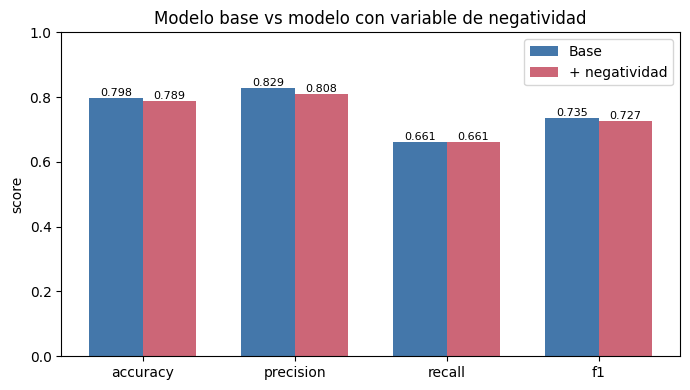

In [9]:
metricas = ["accuracy", "precision", "recall", "f1"]
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(metricas)); w = 0.35
ax.bar(x - w/2, comp.loc["Base (solo TF-IDF)", metricas], w, label="Base", color="#4477aa")
ax.bar(x + w/2, comp.loc["Aumentado (TF-IDF + negatividad)", metricas], w, label="+ negatividad", color="#cc6677")
ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0, 1); ax.set_ylabel("score")
ax.set_title("Modelo base vs modelo con variable de negatividad")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "negatividad_comparacion_modelos.png", dpi=150)
plt.show()

### Validación cruzada 



In [22]:
texts = df["text_final"].to_numpy()
y_all = df["target"].to_numpy()
neg_all = df["negatividad"].to_numpy().reshape(-1, 1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_base_cv, f1_aug_cv = [], []

for tr, va in skf.split(texts, y_all):
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=8000, min_df=2)
    Xtr = vec.fit_transform(texts[tr]); Xva = vec.transform(texts[va])

    m_b = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xtr, y_all[tr])
    f1_base_cv.append(f1_score(y_all[va], m_b.predict(Xva)))

    Xtr_a = hstack([Xtr, csr_matrix(neg_all[tr])]).tocsr()
    Xva_a = hstack([Xva, csr_matrix(neg_all[va])]).tocsr()
    m_a = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xtr_a, y_all[tr])
    f1_aug_cv.append(f1_score(y_all[va], m_a.predict(Xva_a)))

f1_base_cv, f1_aug_cv = np.array(f1_base_cv), np.array(f1_aug_cv)
print("F1 base     por fold:", np.round(f1_base_cv, 4), f"| media {f1_base_cv.mean():.4f} +- {f1_base_cv.std():.4f}")
print("F1 aumentado por fold:", np.round(f1_aug_cv, 4), f"| media {f1_aug_cv.mean():.4f} +- {f1_aug_cv.std():.4f}")
print(f"Diferencia media de F1 (aug - base): {f1_aug_cv.mean() - f1_base_cv.mean():+.4f}")

F1 base     por fold: [0.7463 0.7381 0.7695 0.7448 0.7526] | media 0.7503 +- 0.0107
F1 aumentado por fold: [0.7348 0.7414 0.7624 0.7393 0.7498] | media 0.7455 +- 0.0097
Diferencia media de F1 (aug - base): -0.0047


### Peso que el modelo le da a la variable

In [23]:
coef_neg = modelo_aug.coef_[0, -1]
print(f"Coeficiente de 'negatividad': {coef_neg:.4f}")
print(f"Odds ratio (negatividad 0 -> 1): {np.exp(coef_neg):.3f}")

coefs = modelo_aug.coef_[0]
rank = np.argsort(np.abs(coefs))[::-1]
pos_neg = np.where(rank == len(coefs) - 1)[0][0]
print(f"\n'negatividad' es la feature nº {pos_neg + 1} de {len(coefs)} por magnitud del coeficiente.")

Coeficiente de 'negatividad': 1.5264
Odds ratio (negatividad 0 -> 1): 4.602

'negatividad' es la feature nº 37 de 8001 por magnitud del coeficiente.


## 6. Interpretación


**¿La inclusión de esta variable mejoró los resultados del modelo de clasificación?**
No. El modelo con la variable de negatividad no mejoró; incluso quedó marginalmente por debajo del modelo base.

**Si es así, ¿en qué medida?**
No hubo mejora. La variación fue negativa y despreciable, el F1 bajó de 0.735 a 0.727 en el conjunto de test (−0.008) y de 0.750 a 0.746 en la validación cruzada de 5 folds (−0.005). Esa diferencia es menor que la variabilidad entre folds (desviación = 0.010) y el modelo aumentado no superó al base en ninguno de los 5 folds, así que en la práctica el desempeño de las dos versiones es equivalente.

### Descripción e interpretación de los resultados

Todas las métricas quedaron iguales o levemente por debajo. El recall no cambió (0.661) y la caída se concentró en la precisión (0.829 a 0.808) y la accuracy (0.798 a 0.789). Al agregar la variable, el modelo pasó a marcar como "desastre" algunos tweets negativos que en realidad no lo eran.

La regresión logística sí le da peso a la variable, coeficiente 1.53, odds ratio 4.6, puesto 37 de 8 001 por magnitud del coeficiente, pero ese peso no se traduce en mejor generalización: en el test la variable aporta tanto acierto como error. La información que agrega ya está contenida en los n-gramas, porque muchas palabras negativas (fire, dead, crash) son también las más predictivas de desastre.

El resultado es coherente con el análisis de la sección 2, la negatividad separa poco las clases (media 0.63 en desastres frente a 0.53 en no-desastres, distribuciones muy solapadas, correlación con target de 0.22). Las dos categorías contienen tweets negativos, desastres redactados como noticia con tono neutro, y no desastres que son quejas, sarcasmo o lenguaje violento en sentido figurado, por lo que el sentimiento no es un buen discriminador para esta tarea.

En consecuencia, se conserva el modelo base (solo TF-IDF), más simple y sin dependencia del módulo de análisis de sentimiento.

## 7. Guardar el dataset con la variable incluida
Se guarda `train_final.csv`
con el texto procesado, la etiqueta y las variables de sentimiento usadas.

In [24]:
cols_final = ["id", "keyword", "location", "text", "text_final", "target", "negatividad"]
cols_final = [c for c in cols_final if c in df.columns]
df[cols_final].to_csv("../data/train_final.csv", index=False)
print("Guardado data/train_final.csv:", df[cols_final].shape)
df[cols_final].head()

Guardado data/train_final.csv: (7484, 7)


,id,keyword,location,text,text_final,target,negatividad
0,1,none,unknown,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquake may allah forgive,1,0.3634
1,4,none,unknown,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada,1,0.6700
2,5,none,unknown,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,resident asked shelter place notified officer evacuation shelter place order expected,1,0.6480
3,6,none,unknown,"13,000 people receive #wildfires evacuation orders in California",people receive wildfire evacuation order california,1,0.5000
4,7,none,unknown,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo ruby alaska smoke wildfire pours school,1,0.5000
